# NB2 · Churn Driver Analysis

**Goal**: Identify *which variables* most strongly predict churn, and translate each finding into a plain-English business insight.

Key questions we answer:
- Does contract type explain churn better than anything else?
- Where does the monthly charge cliff sit?
- Is there a tenure 'danger zone' (new customers who leave fast)?
- Which services are correlated with staying vs. leaving?

**Requires**: `telco_clean.csv` produced by NB1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('telco_clean.csv')
print(f'Loaded {df.shape[0]:,} rows. Churn rate: {df["Churn_flag"].mean():.1%}')

Loaded 7,043 rows. Churn rate: 26.5%


## 1 · Churn rate by contract type

The single most predictive categorical variable.  
**Hypothesis**: month-to-month customers churn far more because they face zero switching cost.

                churn_rate     n  churn_rate_pct
Contract                                        
Month-to-month    0.427097  3875            42.7
One year          0.112695  1473            11.3
Two year          0.028319  1695             2.8


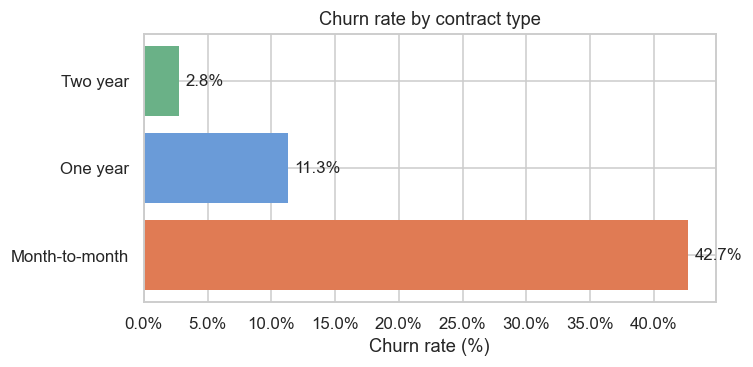


>>> Month-to-month churns 15.3× more than 2-year contract customers.


In [2]:
contract_churn = (
    df.groupby('Contract')['Churn_flag']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'n'})
    .sort_values('churn_rate', ascending=False)
)
contract_churn['churn_rate_pct'] = contract_churn['churn_rate'].mul(100).round(1)
print(contract_churn)

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ['#e07b54', '#6a9bd8', '#6ab187']
bars = ax.barh(contract_churn.index, contract_churn['churn_rate_pct'], color=colors[:len(contract_churn)], edgecolor='none')
for bar, val in zip(bars, contract_churn['churn_rate_pct']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=11)
ax.set_xlabel('Churn rate (%)')
ax.set_title('Churn rate by contract type')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

m2m = contract_churn.loc['Month-to-month', 'churn_rate_pct']
two_yr = contract_churn.loc['Two year', 'churn_rate_pct']
print(f'\n>>> Month-to-month churns {m2m/two_yr:.1f}× more than 2-year contract customers.')

## 2 · Monthly charges vs churn

Are high-paying customers more likely to leave?  
We bin charges and compute churn rate per bin — looking for a 'cliff'.

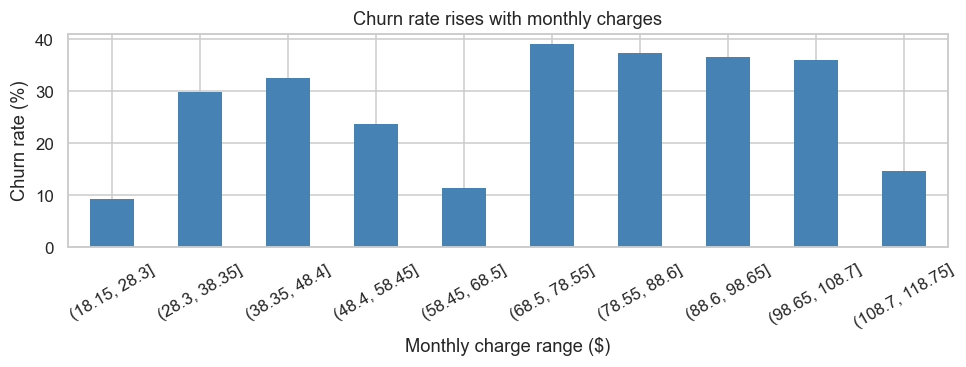

In [3]:
df['charge_bin'] = pd.cut(df['MonthlyCharges'], bins=10)
charge_churn = df.groupby('charge_bin', observed=True)['Churn_flag'].mean().mul(100)

fig, ax = plt.subplots(figsize=(9, 3.5))
charge_churn.plot.bar(ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('Monthly charge range ($)')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn rate rises with monthly charges')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 3 · Tenure vs churn — the 'danger zone'

Churn risk is not flat over time.  
New customers in months 1–12 are the most vulnerable; if they stay past ~24 months, they almost never leave.

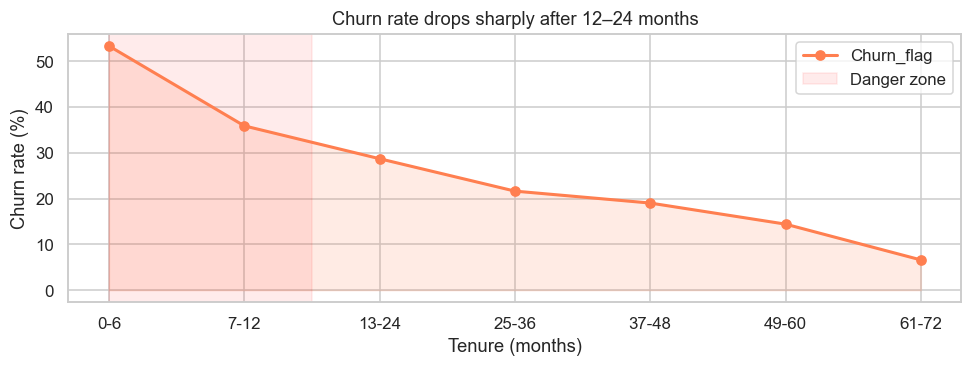

In [4]:
df['tenure_bin'] = pd.cut(df['tenure'], bins=[0,6,12,24,36,48,60,72], labels=['0-6','7-12','13-24','25-36','37-48','49-60','61-72'])
tenure_churn = df.groupby('tenure_bin', observed=True)['Churn_flag'].mean().mul(100)

fig, ax = plt.subplots(figsize=(9, 3.5))
tenure_churn.plot(ax=ax, marker='o', linewidth=2, color='coral')
ax.fill_between(tenure_churn.index, tenure_churn.values, alpha=0.15, color='coral')
ax.axvspan(0, 1.5, alpha=0.08, color='red', label='Danger zone')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn rate drops sharply after 12–24 months')
ax.legend()
plt.tight_layout()
plt.show()

## 4 · Service-level churn rates

Which add-on services (TechSupport, OnlineSecurity, StreamingTV, etc.) are associated with lower churn?  
Customers without protective services may feel less 'locked in'.

                  With service  Without service
Service                                        
OnlineSecurity            14.6             41.8
OnlineBackup              21.5             39.9
DeviceProtection          22.5             39.1
TechSupport               15.2             41.6
StreamingTV               30.1             33.5
StreamingMovies           29.9             33.7


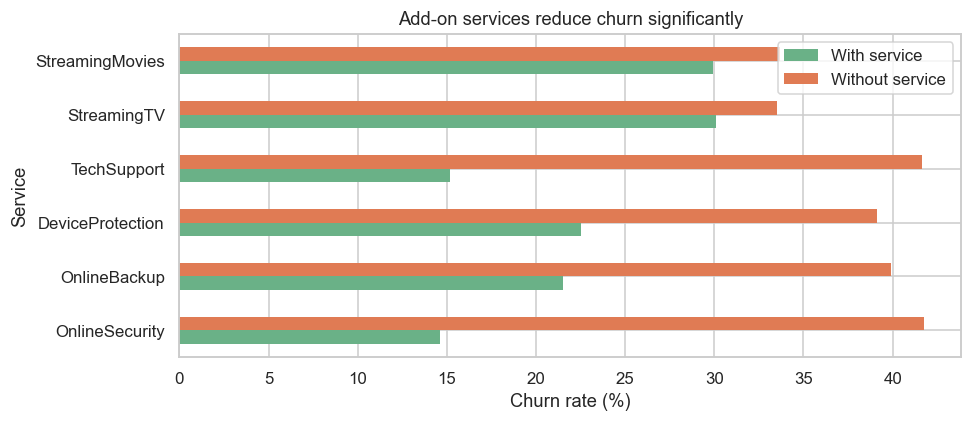

In [5]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

rows = []
for col in service_cols:
    grp = df[df[col].isin(['Yes', 'No'])].groupby(col)['Churn_flag'].mean().mul(100)
    rows.append({'Service': col, 'With service': grp.get('Yes', np.nan), 'Without service': grp.get('No', np.nan)})

svc_df = pd.DataFrame(rows).set_index('Service')
print(svc_df.round(1))

ax = svc_df.plot.barh(figsize=(9, 4), color=['#6ab187', '#e07b54'], edgecolor='none')
ax.set_xlabel('Churn rate (%)')
ax.set_title('Add-on services reduce churn significantly')
plt.tight_layout()
plt.show()

## 5 · Payment method & paperless billing

Electronic-check payers have unusually high churn.  
Paperless billing is also correlated with churn — possibly a digital-native cohort that is more likely to comparison-shop.

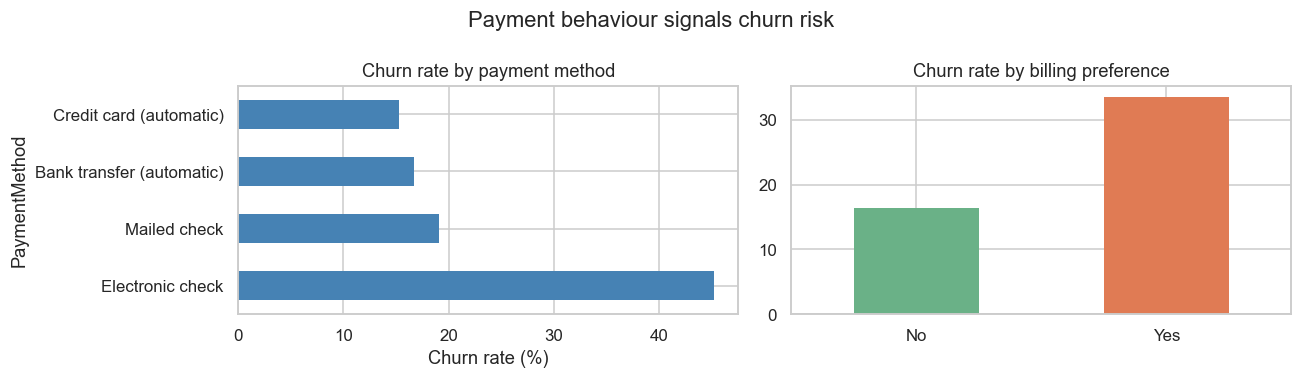

In [6]:
pay_churn = df.groupby('PaymentMethod')['Churn_flag'].mean().mul(100).sort_values(ascending=False)
paper_churn = df.groupby('PaperlessBilling')['Churn_flag'].mean().mul(100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))

pay_churn.plot.barh(ax=ax1, color='steelblue', edgecolor='none')
ax1.set_title('Churn rate by payment method')
ax1.set_xlabel('Churn rate (%)')

paper_churn.plot.bar(ax=ax2, color=['#6ab187', '#e07b54'], edgecolor='none')
ax2.set_title('Churn rate by billing preference')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=0)

plt.suptitle('Payment behaviour signals churn risk')
plt.tight_layout()
plt.show()

## 6 · Churn rate ranked — all categorical columns

A single summary table: for every Yes/No service column, compute the churn rate gap.  
Rank by gap size → tells us which features to prioritise in retention campaigns.

         feature  churn_Yes  churn_No   gap
PaperlessBilling       33.6      16.3  17.2
    PhoneService       26.7      24.9   1.8
         Partner       19.7      33.0 -13.3
      Dependents       15.5      31.3 -15.8


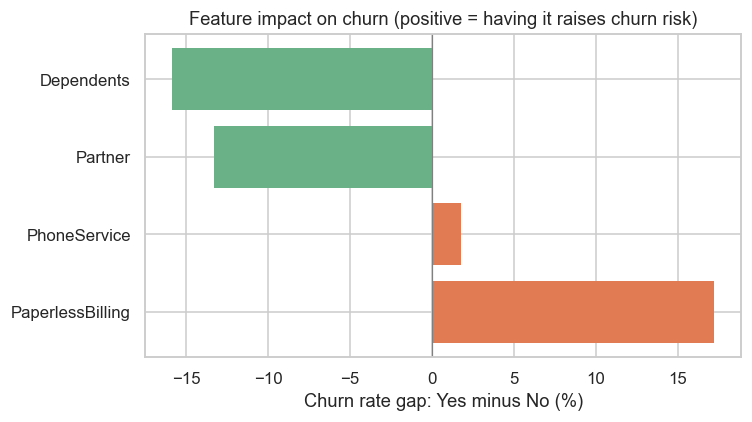

In [7]:
binary_cols = [c for c in df.select_dtypes('object').columns
               if df[c].isin(['Yes','No']).all() and c != 'Churn']

gaps = []
for col in binary_cols:
    rates = df.groupby(col)['Churn_flag'].mean()
    gap = (rates.get('Yes', np.nan) - rates.get('No', np.nan)) * 100
    gaps.append({'feature': col, 'churn_Yes': rates.get('Yes', np.nan)*100,
                 'churn_No': rates.get('No', np.nan)*100, 'gap': gap})

gap_df = pd.DataFrame(gaps).sort_values('gap', ascending=False)
print(gap_df.round(1).to_string(index=False))

# Diverging bar — positive gap = having this feature raises churn
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#e07b54' if g > 0 else '#6ab187' for g in gap_df['gap']]
ax.barh(gap_df['feature'], gap_df['gap'], color=colors, edgecolor='none')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Churn rate gap: Yes minus No (%)')
ax.set_title('Feature impact on churn (positive = having it raises churn risk)')
plt.tight_layout()
plt.show()